In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error

In [2]:
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

### Common Time Series Patterns

A typical time series model can exhibits different patterns.

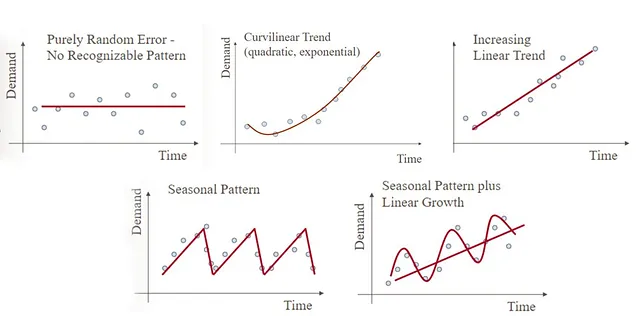

### Read Data Set

In [3]:
df = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\DAYTON_hourly.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121275 entries, 0 to 121274
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Datetime   121275 non-null  object 
 1   DAYTON_MW  121275 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
#set datetime as an index
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index) #change data tipe to datetime

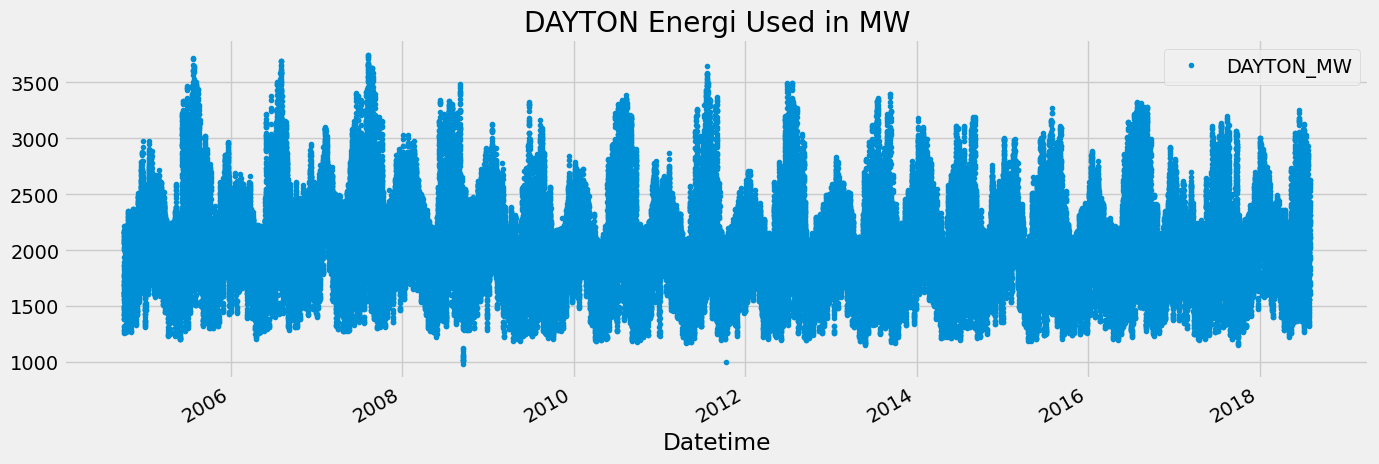

In [7]:
df.plot(
    style='.',
    figsize=(15,5),
    title='DAYTON Energi Used in MW'
)
plt.show()

In [8]:
df['DAYTON_MW'].describe()

count    121275.000000
mean       2037.851140
std         393.403153
min         982.000000
25%        1749.000000
50%        2009.000000
75%        2279.000000
max        3746.000000
Name: DAYTON_MW, dtype: float64

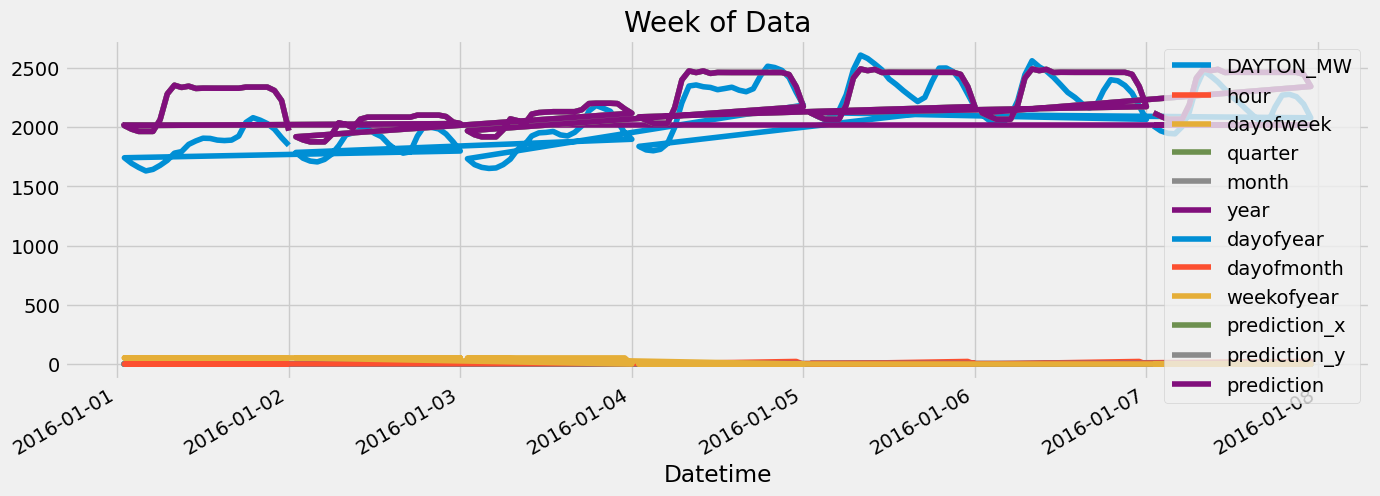

In [76]:
df.loc[(df.index > '2016-01-01') & (df.index < '2016-01-08')]\
    .plot(
        figsize=(15,5),
        title='Week of Data'
    )
plt.show()

In [ ]:
df.loc[(df.index > '01-01-2016') & (df.index < '01-02-2016')]

### Analyze Outlier & Handling

#### BoxPlot & Scatter Plot

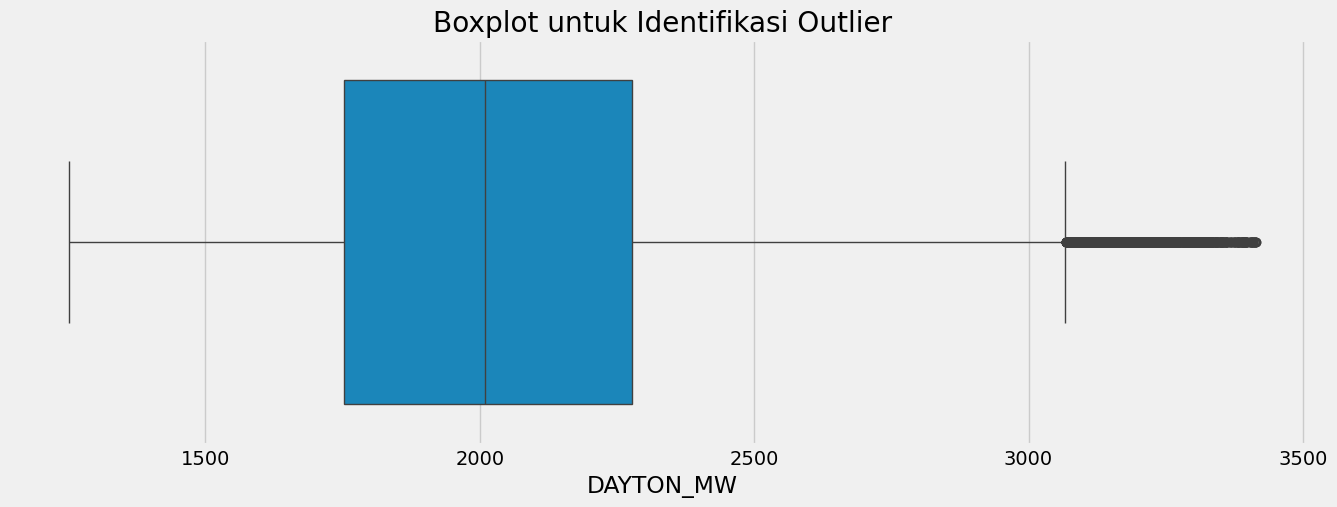

In [40]:
# Visualisasi menggunakan Boxplot
plt.figure(figsize=(15, 5))
sns.boxplot(x=df['DAYTON_MW'])
plt.title('Boxplot untuk Identifikasi Outlier')
plt.show()

#### Use Z-Score

In [9]:
from scipy.stats import zscore

df['Z-Score'] = zscore(df['DAYTON_MW'])

In [10]:
df['Z-Score'].describe()

count    1.212750e+05
mean     1.724871e-16
std      1.000004e+00
min     -2.683902e+00
25%     -7.342400e-01
50%     -7.333764e-02
75%      6.129840e-01
max      4.341999e+00
Name: Z-Score, dtype: float64

In [26]:
outliers = df[(df['Z-Score'] <= -2) | (df['Z-Score'] >= 3.5)]

In [27]:
outliers

,DAYTON_MW,Z-Score
Datetime,,
2005-08-12 16:00:00,3433.0,3.546374
2005-08-12 17:00:00,3437.0,3.556541
2005-08-04 14:00:00,3427.0,3.531122
2005-08-04 15:00:00,3471.0,3.642967
2005-08-04 16:00:00,3500.0,3.716683
...,...,...
2017-03-26 04:00:00,1250.0,-2.002664
2017-03-26 05:00:00,1247.0,-2.010290
2018-05-06 04:00:00,1230.0,-2.053503


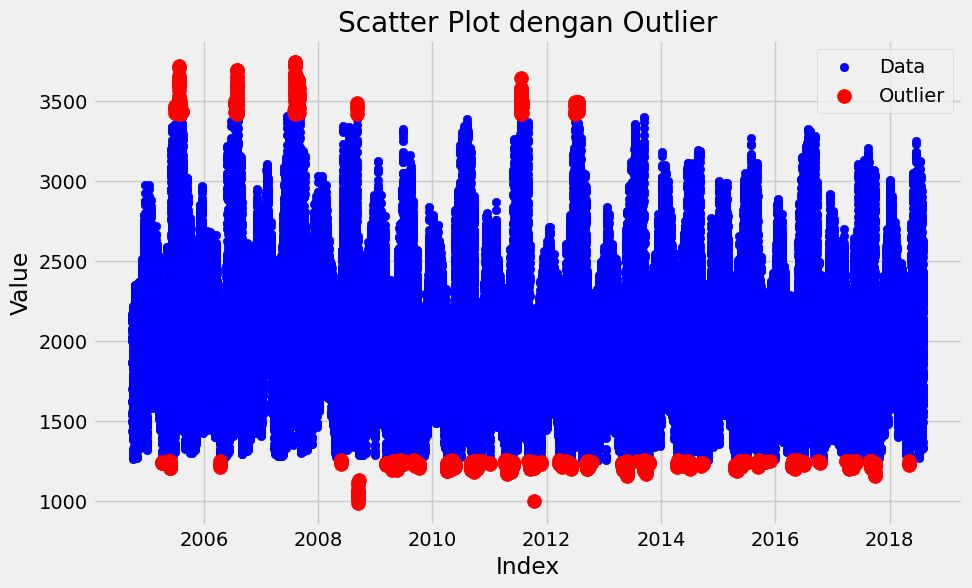

In [34]:
# Visualisasi menggunakan Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['DAYTON_MW'], label='Data', color='blue')

# Menambahkan outlier ke plot
plt.scatter(outliers.index, outliers['DAYTON_MW'], color='red', label='Outlier', s=100)
plt.title('Scatter Plot dengan Outlier')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()

<Axes: ylabel='Frequency'>

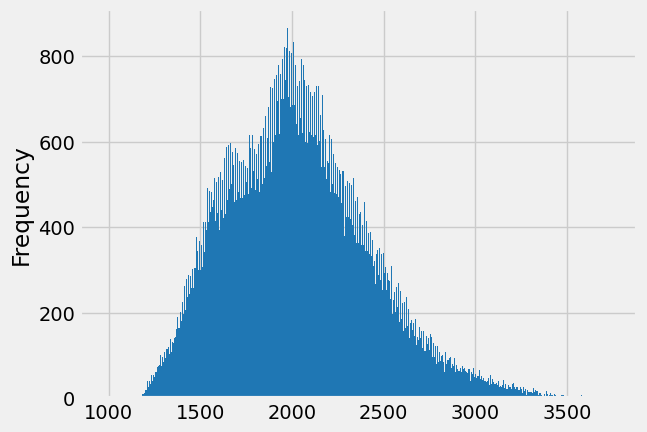

In [28]:
df['DAYTON_MW'].plot(
    kind='hist',
    bins=500,
    color=color_pal[0]
)

<Axes: title={'center': 'Outliers'}, xlabel='Datetime'>

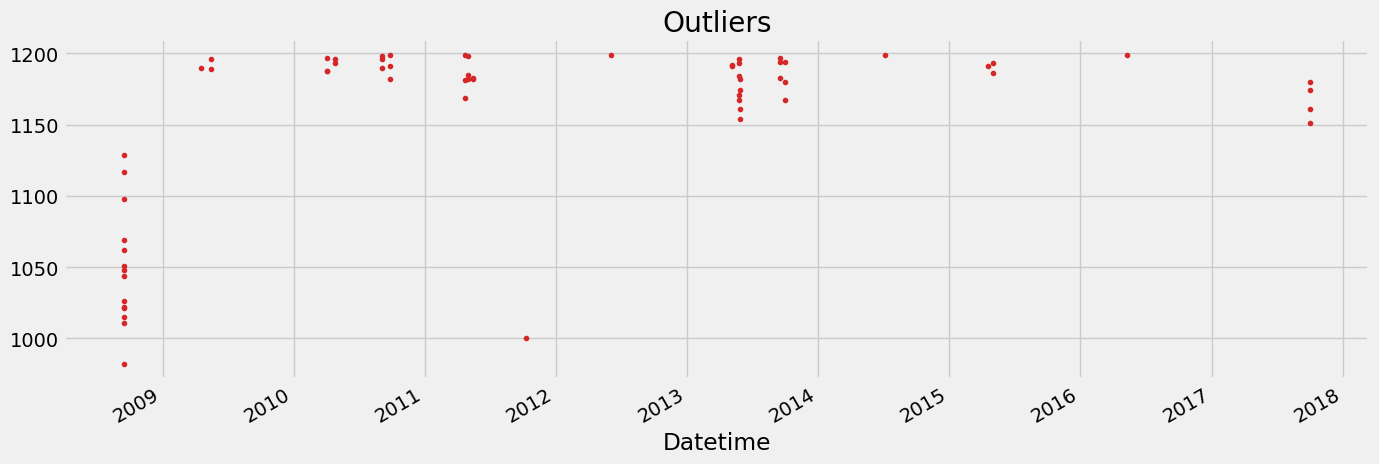

In [35]:
# select and vizualize using plot where value less than 19000
df.query('DAYTON_MW < 1200')['DAYTON_MW']\
    .plot(
        style='.',
        figsize=(15,5),
        color=color_pal[3],
        title='Outliers'
    )

In [36]:
# remove outlier and save new data
# df = df[(df['Z-Score'] > -2) & (df['Z-Score'] < 3.5)]
df = df[~df.index.isin(outliers.index)]

In [37]:
df.describe()

,DAYTON_MW,Z-Score
count,120673.000000,120673.000000
mean,2038.538140,0.001746
std,387.167874,0.984154
min,1252.000000,-1.997580
25%,1752.000000,-0.726614
50%,2010.000000,-0.070796
75%,2278.000000,0.610442
max,3414.000000,3.498077


In [38]:
df = df.drop('Z-Score', axis=1)

In [41]:
df.head()

,DAYTON_MW
Datetime,
2004-12-31 01:00:00,1596.0
2004-12-31 02:00:00,1517.0
2004-12-31 03:00:00,1486.0
2004-12-31 04:00:00,1469.0
2004-12-31 05:00:00,1472.0


### Train & Test Split Data

In [42]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

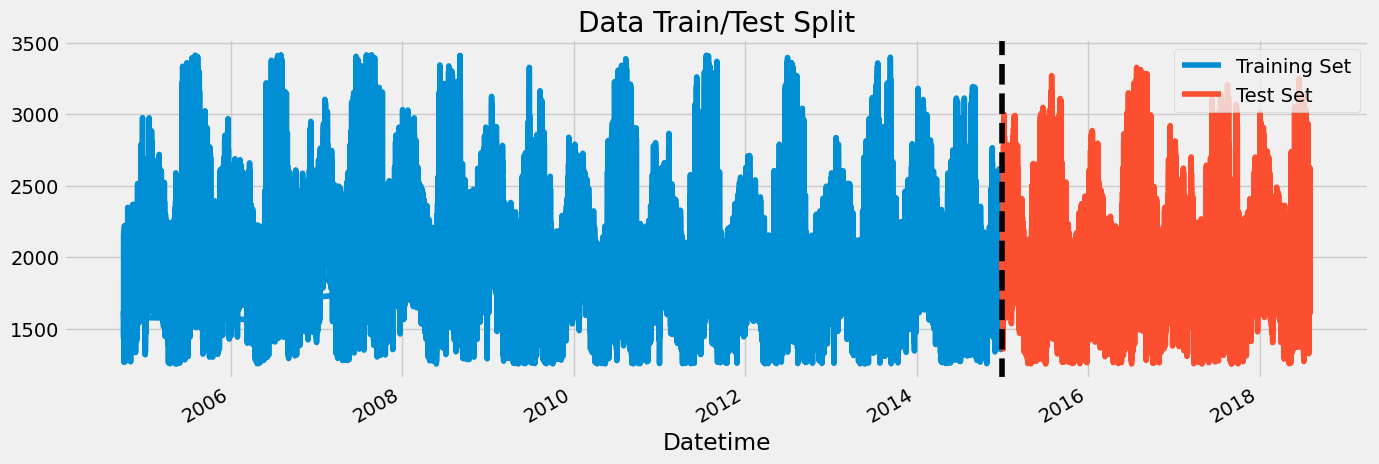

In [43]:
fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

### Create Additional Features

In [45]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

In [47]:
df.tail()

,DAYTON_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2018-01-01 20:00:00,2732.0,20,0,1,1,2018,1,1,1
2018-01-01 21:00:00,2724.0,21,0,1,1,2018,1,1,1
2018-01-01 22:00:00,2664.0,22,0,1,1,2018,1,1,1
2018-01-01 23:00:00,2614.0,23,0,1,1,2018,1,1,1
2018-01-02 00:00:00,2552.0,0,1,1,1,2018,2,2,1


### Visualize Feature / Target Relationship

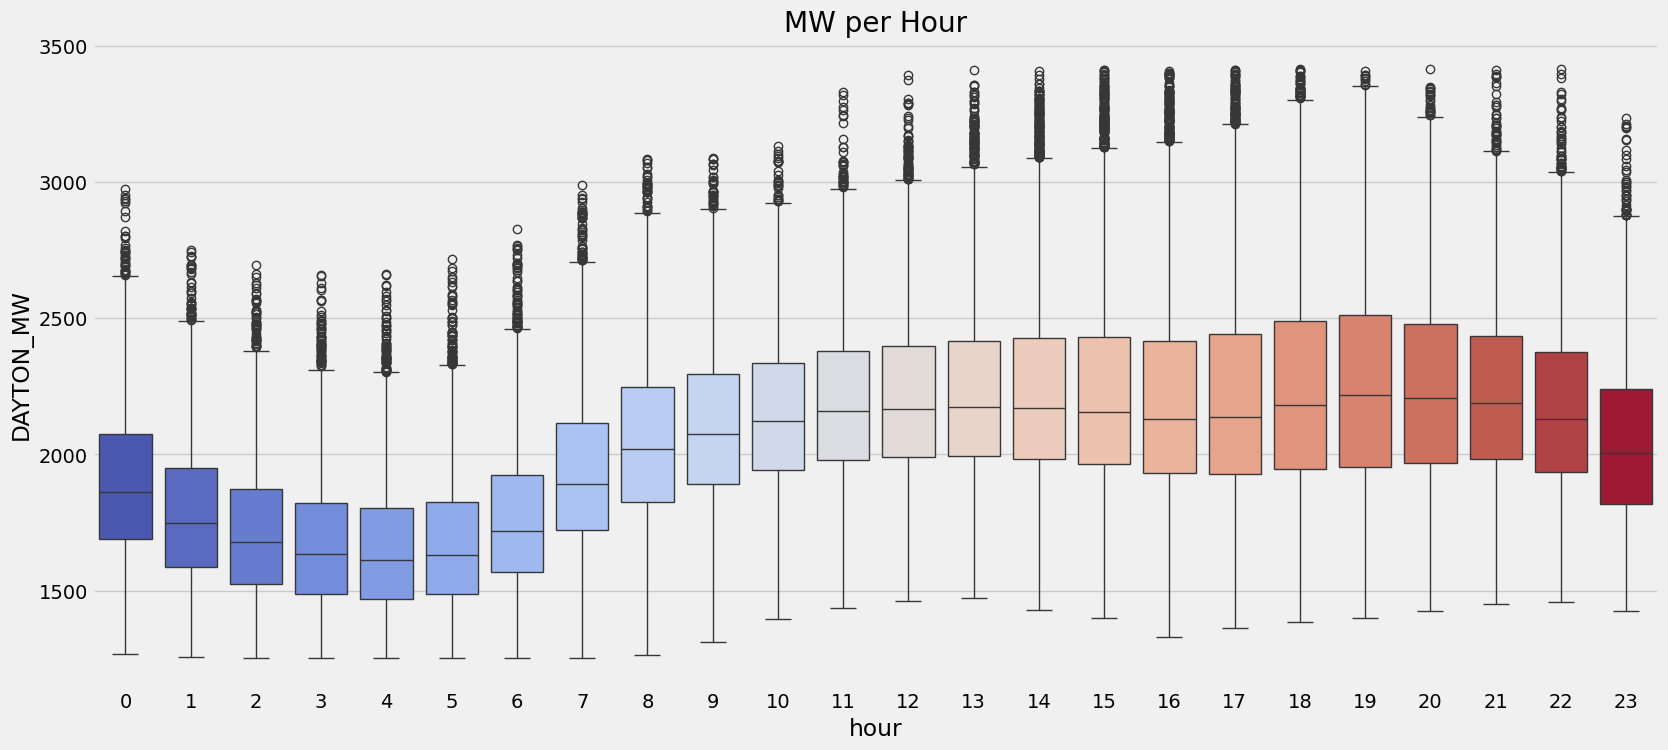

In [55]:
fig, ax = plt.subplots(figsize=(18,8))
sns.boxplot(data=df, x='hour', y='DAYTON_MW', palette='coolwarm', hue='hour', legend=False)
ax.set_title('MW per Hour')
plt.show()

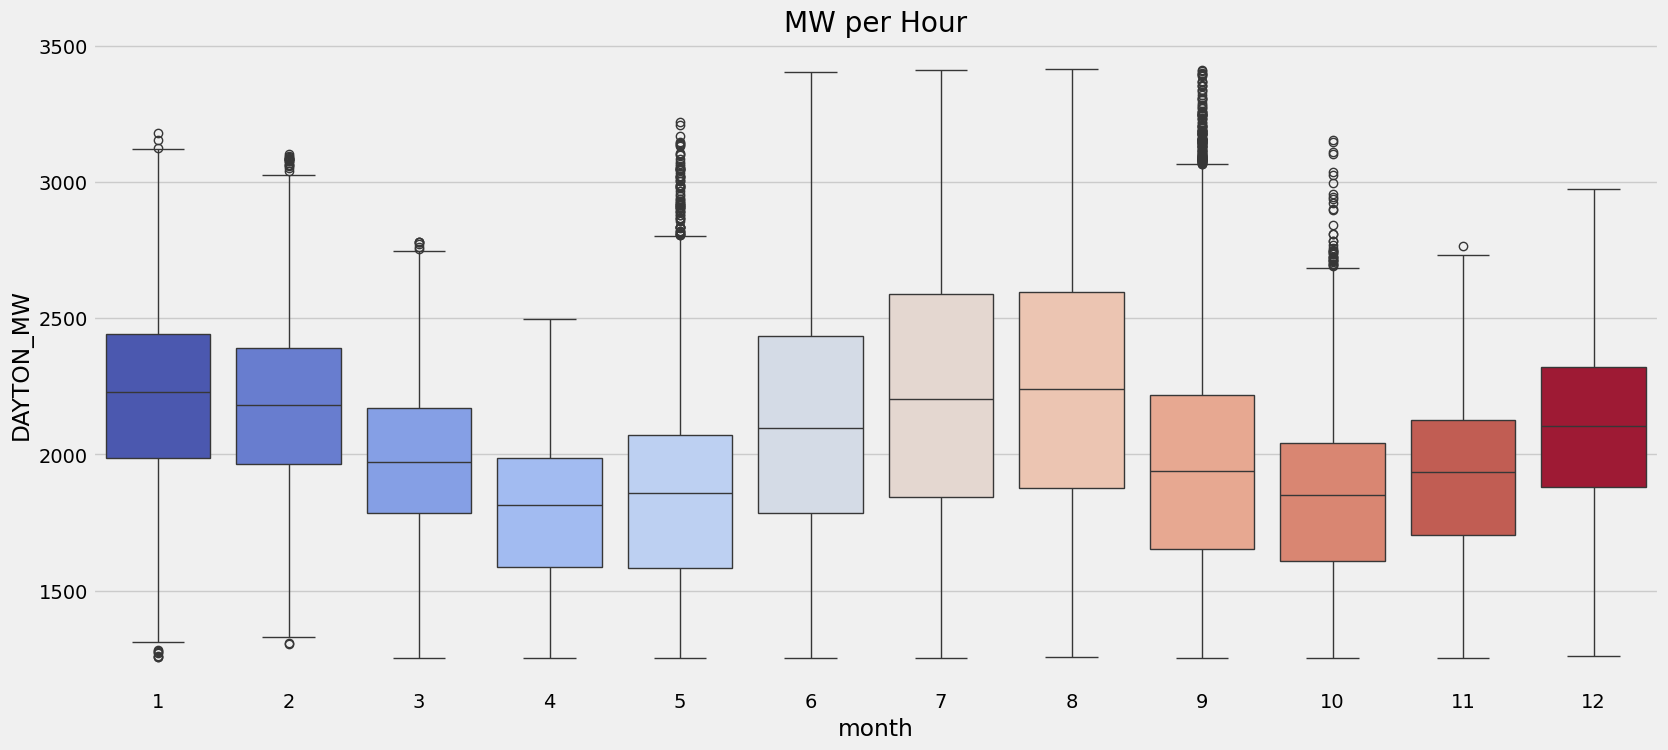

In [56]:
fig, ax = plt.subplots(figsize=(18,8))
sns.boxplot(data=df, x='month', y='DAYTON_MW', palette='coolwarm', hue='month', legend=False)
ax.set_title('MW per Hour')
plt.show()

In [57]:
### Create Model

In [58]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'DAYTON_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [91]:
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:squarederror',
                       max_depth=4,
                       learning_rate=0.01)
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:2063.97405	validation_1-rmse:2025.23972
[100]	validation_0-rmse:792.43265	validation_1-rmse:765.48849
[200]	validation_0-rmse:359.68803	validation_1-rmse:350.01246
[300]	validation_0-rmse:238.83415	validation_1-rmse:245.95626
[400]	validation_0-rmse:209.04308	validation_1-rmse:226.32937
[500]	validation_0-rmse:197.19234	validation_1-rmse:224.01500
[547]	validation_0-rmse:193.97915	validation_1-rmse:224.15945


,objective,'reg:squarederror'
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


### Lag Features

### Features Importance

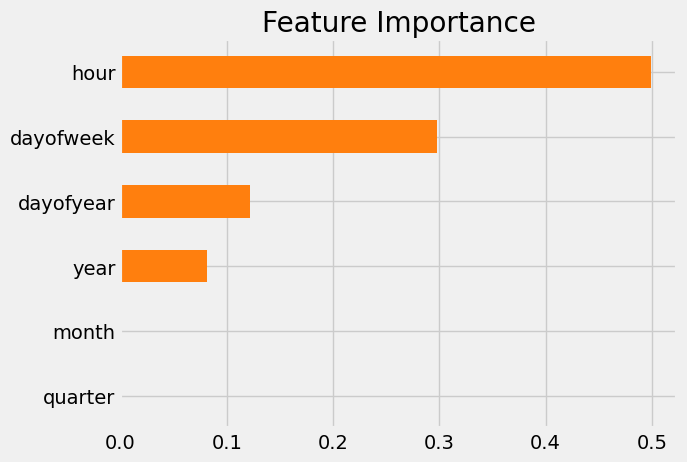

In [80]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance', legend=False, color=color_pal[1])
plt.show()

### Forecast on Test Data

In [84]:
test['prediction'] = reg.predict(X_test)

In [82]:
df

,DAYTON_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction_x,prediction_y,prediction
Datetime,,,,,,,,,,,,
2004-12-31 01:00:00,1596.0,1,4,4,12,2004,366,31,53,NaN,NaN,NaN
2004-12-31 02:00:00,1517.0,2,4,4,12,2004,366,31,53,NaN,NaN,NaN
2004-12-31 03:00:00,1486.0,3,4,4,12,2004,366,31,53,NaN,NaN,NaN
2004-12-31 04:00:00,1469.0,4,4,4,12,2004,366,31,53,NaN,NaN,NaN
2004-12-31 05:00:00,1472.0,5,4,4,12,2004,366,31,53,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,2732.0,20,0,1,1,2018,1,1,1,2411.540771,2411.540771,2411.540771
2018-01-01 21:00:00,2724.0,21,0,1,1,2018,1,1,1,2411.540771,2411.540771,2411.540771
2018-01-01 22:00:00,2664.0,22,0,1,1,2018,1,1,1,2400.556152,2400.556152,2400.556152


In [85]:
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[['DAYTON_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

MergeError: Passing 'suffixes' which cause duplicate columns {'prediction_x'} is not allowed.

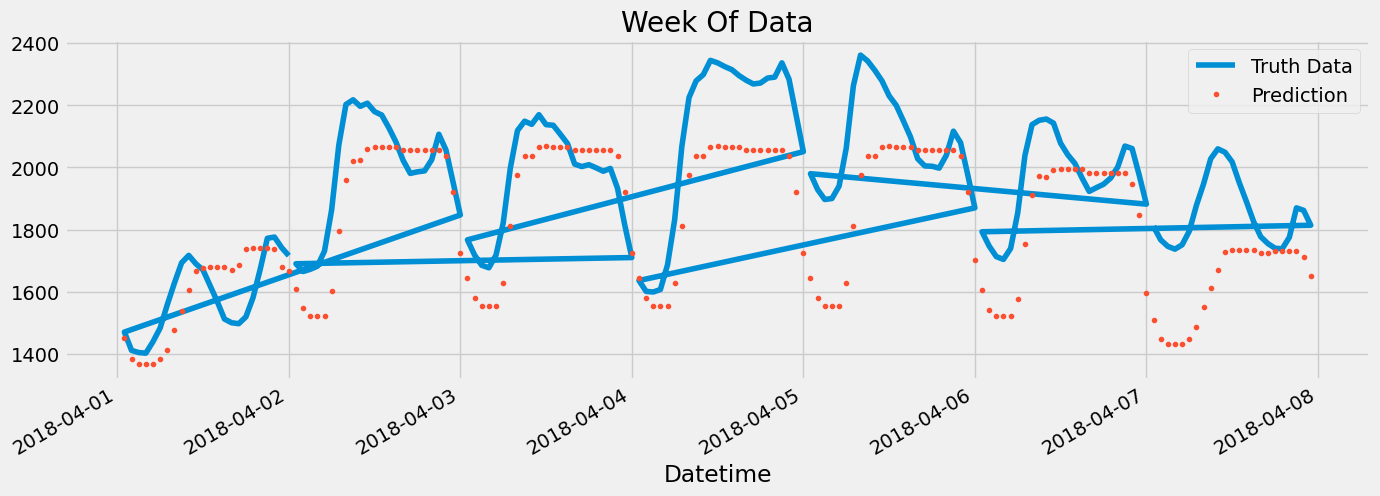

In [86]:
ax = df.loc[(df.index > '2018-04-01') & (df.index < '2018-04-08')]['DAYTON_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df.loc[(df.index > '2018-04-01') & (df.index < '2018-04-08')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

### Score RMSE & Calculate Error

In [87]:
score = np.sqrt(mean_squared_error(test['DAYTON_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.3f}')

RMSE Score on Test set: 778.875


In [88]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(10)

date
2016-07-25    1480.274099
2015-01-08    1440.940806
2018-01-02    1414.940806
2016-08-12    1412.684662
2015-02-19    1401.274139
2016-08-11    1387.982432
2016-12-15    1371.631983
2016-08-05    1356.267995
2018-01-05    1352.955073
2018-01-03    1341.982473
Name: error, dtype: float64